# **FRAMEWORK V7 DATASET MAESTRO - MODELADO**


In [ ]:
# Funciones modulares reutilizables para C14
from pathlib import Path
import sys

PROJECT_SRC = Path.cwd() / "src"
if PROJECT_SRC.exists() and str(PROJECT_SRC) not in sys.path:
    sys.path.insert(0, str(PROJECT_SRC))

from framework_v7.pipeline.modeling import (
    load_model_diagnostic,
    load_model_record,
    load_tensor_metadata,
    summarize_modeling_experiments,
    temporal_split,
    validate_tensors,
)
from framework_v7.pipeline.utils import save_csv_and_excel


## **M0. Configuración del Experimento**

In [1]:
#==========================================================================================
# SCRIPT 32
# CONFIGURACIÓN DEL EXPERIMENTO DE MODELADO
#==========================================================================================

EXPERIMENTO = "Exp01"


In [2]:
#==========================================================================================
# LIBRERÍAS
#==========================================================================================

import numpy as np

import pandas as pd

import tensorflow as tf

from tensorflow import keras

print()

print("="*90)
print("LIBRERÍAS CARGADAS")
print("="*90)


LIBRERÍAS CARGADAS


In [3]:
#==========================================================================================
# CARGA DE SECUENCIAS TEMPORALES Y REGISTRO DE PREPARACION
#==========================================================================================
import numpy as np
import pandas as pd

# Base URL for the sequences and metadata
base_url = f"https://raw.githubusercontent.com/jriatiga/FRAMEWORK_V7/refs/heads/main/DATA/MACHINE_LEARNING/C13_MACHINE_LEARNING/Transformaciones/{EXPERIMENTO}/"

# URLs completas de los archivos
x_sequence_url = base_url + "secuencias_X.npy"
y_sequence_url = base_url + "secuencias_y.npy"
metadata_sequence_url = base_url + "metadata_secuencias.csv"

# Nombres de archivo locales
x_sequence_filename = "secuencias_X.npy"
y_sequence_filename = "secuencias_y.npy"
metadata_sequence_filename = "metadata_secuencias.csv"

# Descargar los archivos
!wget -O {x_sequence_filename} {x_sequence_url}
!wget -O {y_sequence_filename} {y_sequence_url}
!wget -O {metadata_sequence_filename} {metadata_sequence_url}

secuencias_X = np.load(x_sequence_filename)
secuencias_y = np.load(y_sequence_filename)
metadata = pd.read_csv(metadata_sequence_filename)

print()

print("="*90)
print("SECUENCIAS CARGADAS")
print("="*90)

print()

print(f"Secuencias X : {secuencias_X.shape}")

print(f"Secuencias y : {secuencias_y.shape}")

print()

display(metadata)

--2026-08-11 16:22:23--  https://raw.githubusercontent.com/jriatiga/FRAMEWORK_V7/refs/heads/main/DATA/MACHINE_LEARNING/C13_MACHINE_LEARNING/Transformaciones/Exp01/secuencias_X.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 396416 (387K) [application/octet-stream]
Saving to: ‘secuencias_X.npy’

secuencias_X.npy    100%[===================>] 387.12K  --.-KB/s    in 0.004s  

2026-08-11 16:22:23 (103 MB/s) - ‘secuencias_X.npy’ saved [396416/396416]

--2026-08-11 16:22:23--  https://raw.githubusercontent.com/jriatiga/FRAMEWORK_V7/refs/heads/main/DATA/MACHINE_LEARNING/C13_MACHINE_LEARNING/Transformaciones/Exp01/secuencias_y.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting

,Parametro,Valor
0,Experimento,Exp01
1,Dominio,Gestión Hídrica
2,Tipo Problema,Clasificación
3,Modelo,LSTM
4,Variable Objetivo,irca
5,Ventana,12
6,Horizonte,1
7,Variables Predictoras,Precipitacion_mm;ONI;Radiacion_Solar;Humedad_R...
8,Variables Modelo,8
9,Numero de Secuencias,516


In [4]:
# URL y nombre de archivo para registro_preparacion.xlsx
registro_preparacion_url = base_url + "registro_preparacion.xlsx"
registro_preparacion_filename = "registro_preparacion.xlsx"

# Descargar el archivo
!wget -O {registro_preparacion_filename} {registro_preparacion_url}

registro_preparacion = pd.read_excel(registro_preparacion_filename)

print()
print("="*90)
print("REGISTRO DE PREPARACIÓN CARGADO")
print("="*90)
print()
display(registro_preparacion)

--2026-08-11 16:22:24--  https://raw.githubusercontent.com/jriatiga/FRAMEWORK_V7/refs/heads/main/DATA/MACHINE_LEARNING/C13_MACHINE_LEARNING/Transformaciones/Exp01/registro_preparacion.xlsx
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5183 (5.1K) [application/octet-stream]
Saving to: ‘registro_preparacion.xlsx’

registro_preparacio 100%[===================>]   5.06K  --.-KB/s    in 0s      

2026-08-11 16:22:25 (46.8 MB/s) - ‘registro_preparacion.xlsx’ saved [5183/5183]


REGISTRO DE PREPARACIÓN CARGADO



,Parametro,Valor
0,Experimento,Exp01
1,Dominio,Gestión Hídrica
2,Variable Objetivo,irca
3,Ventana Temporal,12
4,Horizonte,1
5,Variables Predictoras,8
6,Observaciones,528
7,Número de Secuencias,516
8,Método de Transformación,RobustScaler


In [5]:
registro_preparacion = pd.read_excel("registro_preparacion.xlsx")

DOMINIO = registro_preparacion.loc[
    registro_preparacion["Parametro"]=="Dominio",
    "Valor"
].iloc[0]

VARIABLE_OBJETIVO = registro_preparacion.loc[
    registro_preparacion["Parametro"]=="Variable Objetivo",
    "Valor"
].iloc[0]

VENTANA = int(
    registro_preparacion.loc[
        registro_preparacion["Parametro"]=="Ventana Temporal",
        "Valor"
    ].iloc[0]
)

HORIZONTE = int(
    registro_preparacion.loc[
        registro_preparacion["Parametro"]=="Horizonte",
        "Valor"
    ].iloc[0]
)

METODO_TRANSFORMACION = registro_preparacion.loc[
    registro_preparacion["Parametro"]=="Método de Transformación",
    "Valor"
].iloc[0]

In [6]:
display(registro_preparacion)

,Parametro,Valor
0,Experimento,Exp01
1,Dominio,Gestión Hídrica
2,Variable Objetivo,irca
3,Ventana Temporal,12
4,Horizonte,1
5,Variables Predictoras,8
6,Observaciones,528
7,Número de Secuencias,516
8,Método de Transformación,RobustScaler


In [7]:
#==========================================================================================
# VALIDACIÓN DEL EXPERIMENTO
#==========================================================================================

print()

print("="*90)
print("VALIDACIÓN")
print("="*90)

print()

if len(secuencias_X) != len(secuencias_y):

    raise Exception(

        "Las secuencias X y y no tienen la misma cantidad de registros."

    )

print("Secuencias consistentes.")

print()

print(f"Número de muestras : {len(secuencias_X)}")


VALIDACIÓN

Secuencias consistentes.

Número de muestras : 516


## **M1. Construcción de Tensores**

In [8]:
#==========================================================================================
# CONSTRUCCIÓN DEL TENSOR X
#==========================================================================================

X = np.array(

    secuencias_X,

    dtype=np.float32

)

print()

print("="*90)
print("TENSOR X")
print("="*90)

print()

print(f"Forma : {X.shape}")


TENSOR X

Forma : (516, 12, 8)


In [9]:
#==========================================================================================
# CONSTRUCCIÓN DEL TENSOR y
#==========================================================================================

y = np.array(

    secuencias_y,

    dtype=np.float32

)

print()

print("="*90)
print("TENSOR y")
print("="*90)

print()

print(f"Forma : {y.shape}")


TENSOR y

Forma : (516,)


In [10]:
#==========================================================================================
# VALIDACIÓN DE LOS TENSORES
#==========================================================================================

print()

print("="*90)
print("VALIDACIÓN")
print("="*90)

print()

print(f"Tensor X : {X.shape}")

print(f"Tensor y : {y.shape}")

print()

print(f"Ventana temporal      : {X.shape[1]}")

print(f"Variables predictoras : {X.shape[2]}")

print()

if X.shape[0] == y.shape[0]:

    print("Resultado : TENSORES VÁLIDOS")

else:

    raise Exception(

        "El número de muestras entre X e y no coincide."

    )


VALIDACIÓN

Tensor X : (516, 12, 8)
Tensor y : (516,)

Ventana temporal      : 12
Variables predictoras : 8

Resultado : TENSORES VÁLIDOS


In [11]:
#==========================================================================================
# EXPORTACIÓN DEL TENSOR X
#==========================================================================================

import os

CARPETA_TENSORES = f"tensores/{EXPERIMENTO}"

os.makedirs(

    CARPETA_TENSORES,

    exist_ok=True

)

np.save(

    f"{CARPETA_TENSORES}/tensor_X.npy",

    X

)

print()

print("="*90)
print("TENSOR X EXPORTADO")
print("="*90)

print()

print(f"{CARPETA_TENSORES}/tensor_X.npy")


TENSOR X EXPORTADO

tensores/Exp01/tensor_X.npy


In [12]:
#==========================================================================================
# EXPORTACIÓN DEL TENSOR y
#==========================================================================================

np.save(

    f"{CARPETA_TENSORES}/tensor_y.npy",

    y

)

print()

print("="*90)
print("TENSOR y EXPORTADO")
print("="*90)

print()

print(f"{CARPETA_TENSORES}/tensor_y.npy")


TENSOR y EXPORTADO

tensores/Exp01/tensor_y.npy


In [13]:
#==========================================================================================
# METADATA DEL TENSOR
#==========================================================================================

HORIZONTE = metadata.loc[
    metadata["Parametro"] == "Horizonte",
    "Valor"
].iloc[0]

# Recuperar nombres de las variables desde metadata_secuencias
VARIABLES_MODELO = (
    metadata.loc[
        metadata["Parametro"] == "Variables Predictoras",
        "Valor"
    ]
    .iloc[0]
)

metadata_tensor = pd.DataFrame({

    "Parametro":[

        "Experimento",

        "Dominio",

        "Variable Objetivo",

        "Ventana",

        "Horizonte",

        "Variables Predictoras",

        "Variables Modelo",

        "Metodo Transformacion",

        "Numero Secuencias",

        "Fecha Generacion",

        "Tensor X",

        "Tensor y"

    ],

    "Valor":[

        EXPERIMENTO,

        DOMINIO,

        VARIABLE_OBJETIVO,

        X.shape[1],

        HORIZONTE,

        X.shape[2],

        VARIABLES_MODELO,

        METODO_TRANSFORMACION,

        X.shape[0],

        pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"),

        "tensor_X.npy",

        "tensor_y.npy"

    ]

})

#==========================================================================================
# EXPORTACIÓN DE LA METADATA
#==========================================================================================

metadata_tensor.to_csv(

    f"{CARPETA_TENSORES}/metadata_tensor.csv",

    index=False,

    encoding="utf-8-sig"

)

metadata_tensor.to_excel(

    f"{CARPETA_TENSORES}/metadata_tensor.xlsx",

    index=False

)

print()

print("="*90)
print("METADATA DEL TENSOR EXPORTADA")
print("="*90)

print()

print(f"{CARPETA_TENSORES}/metadata_tensor.csv")

print(f"{CARPETA_TENSORES}/metadata_tensor.xlsx")

print()

display(metadata_tensor)



METADATA DEL TENSOR EXPORTADA

tensores/Exp01/metadata_tensor.csv
tensores/Exp01/metadata_tensor.xlsx



,Parametro,Valor
0,Experimento,Exp01
1,Dominio,Gestión Hídrica
2,Variable Objetivo,irca
3,Ventana,12
4,Horizonte,1
5,Variables Predictoras,8
6,Variables Modelo,Precipitacion_mm;ONI;Radiacion_Solar;Humedad_R...
7,Metodo Transformacion,RobustScaler
8,Numero Secuencias,516
9,Fecha Generacion,2026-08-11 16:22


## **M2. División Temporal del Conjunto de Datos**

Objetivo: Dividir los tensores en:

* Entrenamiento (70%)
* Validación (15%)
* Prueba (15%)

manteniendo el orden temporal.

In [14]:
#==========================================================================================
# CONFIGURACIÓN DE LA DIVISIÓN TEMPORAL
#==========================================================================================

PORCENTAJE_TRAIN = 0.70

PORCENTAJE_VALIDACION = 0.15

PORCENTAJE_PRUEBA = 0.15

print()

print("="*90)
print("CONFIGURACIÓN DE LA DIVISIÓN")
print("="*90)

print()

print(f"Entrenamiento : {PORCENTAJE_TRAIN:.0%}")
print(f"Validación    : {PORCENTAJE_VALIDACION:.0%}")
print(f"Prueba        : {PORCENTAJE_PRUEBA:.0%}")


CONFIGURACIÓN DE LA DIVISIÓN

Entrenamiento : 70%
Validación    : 15%
Prueba        : 15%


In [15]:
#==========================================================================================
# CÁLCULO DE LOS ÍNDICES
#==========================================================================================

n = len(X)

indice_train = int(n * PORCENTAJE_TRAIN)

indice_validacion = int(n * (PORCENTAJE_TRAIN + PORCENTAJE_VALIDACION))

print()

print("="*90)
print("ÍNDICES DE CORTE")
print("="*90)

print()

print(f"Total muestras       : {n}")

print(f"Fin entrenamiento    : {indice_train}")

print(f"Fin validación       : {indice_validacion}")


ÍNDICES DE CORTE

Total muestras       : 516
Fin entrenamiento    : 361
Fin validación       : 438


In [16]:
#==========================================================================================
# DIVISIÓN TEMPORAL
#==========================================================================================

X_train = X[:indice_train]

y_train = y[:indice_train]

X_valid = X[indice_train:indice_validacion]

y_valid = y[indice_train:indice_validacion]

X_test = X[indice_validacion:]

y_test = y[indice_validacion:]

In [17]:
#==========================================================================================
# RESUMEN DE LA DIVISIÓN
#==========================================================================================

print()

print("="*90)
print("RESUMEN")
print("="*90)

print()

print(f"Entrenamiento : {X_train.shape}")

print(f"Validación    : {X_valid.shape}")

print(f"Prueba        : {X_test.shape}")


RESUMEN

Entrenamiento : (361, 12, 8)
Validación    : (77, 12, 8)
Prueba        : (78, 12, 8)


In [18]:
#==========================================================================================
# VALIDACIÓN DE LA DIVISIÓN
#==========================================================================================

print()

print("="*90)
print("VALIDACIÓN")
print("="*90)

print()

print(f"Total muestras : {len(X)}")

print(

    f"Total dividido : "

    f"{len(X_train)+len(X_valid)+len(X_test)}"

)

if len(X) == len(X_train)+len(X_valid)+len(X_test):

    print()

    print("Resultado : DIVISIÓN CORRECTA")

else:

    raise Exception(

        "La división temporal presenta inconsistencias."

    )


VALIDACIÓN

Total muestras : 516
Total dividido : 516

Resultado : DIVISIÓN CORRECTA


In [19]:
print('\n==========================================================================================')
print('RANGO DE VALORES DE Y')
print('==========================================================================================\n')

print(f"y_train - Min: {y_train.min():.4f}, Max: {y_train.max():.4f}")
print(f"y_valid - Min: {y_valid.min():.4f}, Max: {y_valid.max():.4f}")
print(f"y_test  - Min: {y_test.min():.4f}, Max: {y_test.max():.4f}")


RANGO DE VALORES DE Y

y_train - Min: 0.0000, Max: 1.0000
y_valid - Min: 0.0000, Max: 1.0000
y_test  - Min: 0.0000, Max: 1.0000


## **M3. Construcción del Modelo de Machine Learning**

In [20]:
#==========================================================================================
# CONFIGURACIÓN DEL MODELO
#==========================================================================================

TIPO_MODELO = "LSTM"

UNIDADES_LSTM = 32

DROPOUT = 0.20

ACTIVACION = "tanh"

print()

print("="*90)
print("CONFIGURACIÓN DEL MODELO")
print("="*90)

print()

print(f"Modelo              : {TIPO_MODELO}")

print(f"Neuronas LSTM       : {UNIDADES_LSTM}")

print(f"Dropout             : {DROPOUT}")

print(f"Activación          : {ACTIVACION}")


CONFIGURACIÓN DEL MODELO

Modelo              : LSTM
Neuronas LSTM       : 32
Dropout             : 0.2
Activación          : tanh


In [21]:
#==========================================================================================
# CONSTRUCCIÓN DEL MODELO
#==========================================================================================

from tensorflow import keras

if TIPO_MODELO == "LSTM":


    modelo = keras.Sequential([

        keras.layers.Input(
            shape=(
                X_train.shape[1],
                X_train.shape[2]
            )
        ),

        keras.layers.LSTM(
            units=UNIDADES_LSTM,
            activation=ACTIVACION
        ),

        keras.layers.Dropout(
            DROPOUT
        ),

        keras.layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

else:

    raise Exception(

        f"Modelo '{TIPO_MODELO}' no soportado por el Framework."

    )

## **M4. Configuración del Entrenamiento**

In [22]:
#==========================================================================================
# CONFIGURACIÓN DEL ENTRENAMIENTO
#==========================================================================================

EPOCAS = 100

BATCH_SIZE = 32

LEARNING_RATE = 0.001

PACIENCIA = 10

print()

print("="*90)
print("CONFIGURACIÓN DEL ENTRENAMIENTO")
print("="*90)

print()

print(f"Épocas           : {EPOCAS}")

print(f"Batch Size       : {BATCH_SIZE}")

print(f"Learning Rate    : {LEARNING_RATE}")

print(f"Early Stopping   : {PACIENCIA}")

USAR_CLASS_WEIGHT = False      # Exp01
# USAR_CLASS_WEIGHT = True     # Exp01-V2
USAR_SMOTE = False            # Exp01-V3


CONFIGURACIÓN DEL ENTRENAMIENTO

Épocas           : 100
Batch Size       : 32
Learning Rate    : 0.001
Early Stopping   : 10


In [23]:
#==========================================================================================
# EARLY STOPPING
#==========================================================================================

import tensorflow as tf

early_stopping = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=PACIENCIA,

    restore_best_weights=True

)

print()

print("="*90)
print("CALLBACKS")
print("="*90)

print()

print("EarlyStopping configurado correctamente.")


CALLBACKS

EarlyStopping configurado correctamente.


In [24]:
TIPO_PROBLEMA = metadata.loc[
    metadata["Parametro"] == "Tipo Problema",
    "Valor"
].iloc[0]

In [25]:
#==========================================================================================
# COMPILACIÓN DEL MODELO
#==========================================================================================

if TIPO_PROBLEMA.lower() == "clasificación":

    LOSS = "binary_crossentropy"

    METRICAS = [

        tf.keras.metrics.BinaryAccuracy(name="accuracy")

    ]

elif TIPO_PROBLEMA.lower() == "regresión":

    LOSS = "mse"

    METRICAS = [

        tf.keras.metrics.MeanAbsoluteError(name="mae"),

        tf.keras.metrics.RootMeanSquaredError(name="rmse")

    ]

else:

    raise ValueError(
        f"Tipo de problema no soportado: {TIPO_PROBLEMA}"
    )

modelo.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=LEARNING_RATE

    ),

    loss=LOSS,

    metrics=METRICAS

)

print()

print("="*90)
print("MODELO COMPILADO")
print("="*90)

print()

print(f"Tipo problema : {TIPO_PROBLEMA}")
print(f"Loss          : {LOSS}")

print("Métricas:")

for m in METRICAS:

    if hasattr(m, "name"):

        print(f" - {m.name}")

    else:

        print(f" - {m}")

print()

print("Compilación finalizada correctamente.")


MODELO COMPILADO

Tipo problema : Clasificación
Loss          : binary_crossentropy
Métricas:
 - accuracy

Compilación finalizada correctamente.


In [26]:
#==========================================================================================
# M4.4 BALANCEO AUTOMÁTICO DE CLASES
#==========================================================================================

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weight = None

if USAR_CLASS_WEIGHT:

    clases = np.unique(y_train)

    pesos = compute_class_weight(

        class_weight="balanced",

        classes=clases,

        y=y_train

    )

    class_weight = dict(zip(clases, pesos))

    print()
    print("="*90)
    print("BALANCEO AUTOMÁTICO DE CLASES")
    print("="*90)
    print()
    print(class_weight)

else:

    print()
    print("="*90)
    print("BALANCEO AUTOMÁTICO DE CLASES")
    print("="*90)
    print()
    print("No se utiliza balanceo de clases en este experimento.")


BALANCEO AUTOMÁTICO DE CLASES

No se utiliza balanceo de clases en este experimento.


In [27]:
#==========================================================================================
# M4.5
# BALANCEO MEDIANTE SMOTE
#==========================================================================================

from imblearn.over_sampling import SMOTE

VENTANA = X_train.shape[1] # Define VENTANA here

if USAR_SMOTE:

    smote = SMOTE(

        random_state=42

    )

    X_train_smote, y_train_smote = smote.fit_resample(

        X_train.reshape(

            X_train.shape[0],
            X_train.shape[1] * X_train.shape[2]

        ),

        y_train

    )

    X_train_smote = X_train_smote.reshape(

        X_train_smote.shape[0],
        VENTANA,
        X_train.shape[2]

    )

    print()

    print("="*90)
    print("SMOTE APLICADO")
    print("="*90)

    print()

    print(X_train_smote.shape)

    print(y_train_smote.shape)

else:

    print()
    print("="*90)
    print("SMOTE NO APLICADO")
    print("="*90)
    print()
    print("No se utiliza SMOTE en este experimento.")


SMOTE NO APLICADO

No se utiliza SMOTE en este experimento.


## **M5. Entrenamiento del Modelo**

In [28]:
#==========================================================================================
# M5
# ENTRENAMIENTO DEL MODELO
#==========================================================================================

import time

#----------------------------------------------------
# Selección automática del conjunto de entrenamiento
#----------------------------------------------------

if USAR_SMOTE:

    X_entrenamiento = X_train_smote
    y_entrenamiento = y_train_smote

else:

    X_entrenamiento = X_train
    y_entrenamiento = y_train

print()

print("="*90)
print("CONJUNTO DE ENTRENAMIENTO SELECCIONADO")
print("="*90)

print()

print(f"X_entrenamiento : {X_entrenamiento.shape}")
print(f"y_entrenamiento : {y_entrenamiento.shape}")

if USAR_SMOTE:

    print("Balanceo utilizado : SMOTE")

elif USAR_CLASS_WEIGHT:

    print("Balanceo utilizado : Class Weight")

else:

    print("Balanceo utilizado : Ninguno")

#----------------------------------------------------
# Entrenamiento
#----------------------------------------------------

inicio = time.time()

historial = modelo.fit(

    X_entrenamiento,

    y_entrenamiento,

    validation_data=(

        X_valid,
        y_valid

    ),

    epochs=EPOCAS,

    batch_size=BATCH_SIZE,

    callbacks=[

        early_stopping

    ],

    verbose=1,

    class_weight=class_weight

)

fin = time.time()

TIEMPO_ENTRENAMIENTO = fin - inicio

print()

print("="*90)
print("ENTRENAMIENTO FINALIZADO")
print("="*90)

print()

print(f"Tiempo de entrenamiento : {TIEMPO_ENTRENAMIENTO:.2f} segundos")


CONJUNTO DE ENTRENAMIENTO SELECCIONADO

X_entrenamiento : (361, 12, 8)
y_entrenamiento : (361,)
Balanceo utilizado : Ninguno
Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.6260 - loss: 0.6592 - val_accuracy: 0.5844 - val_loss: 0.6813
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9114 - loss: 0.5492 - val_accuracy: 0.5065 - val_loss: 0.6703
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9280 - loss: 0.4357 - val_accuracy: 0.5325 - val_loss: 0.6652
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9335 - loss: 0.3233 - val_accuracy: 0.6234 - val_loss: 0.6750
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9335 - loss: 0.2460 - val_accuracy: 0.7662 - val_loss: 0.6920
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9335 - loss: 0.2318 - val_accuracy: 0.7922 - val_loss: 0.6830
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9335 - loss: 0.2210 - val_accuracy: 0.83

In [29]:
#==========================================================================================
# RESUMEN DEL ENTRENAMIENTO
#==========================================================================================

print()

print("="*90)
print("ENTRENAMIENTO FINALIZADO")
print("="*90)

print()

print(f"Épocas ejecutadas : {len(historial.history['loss'])}")

print(f"Tiempo (segundos) : {TIEMPO_ENTRENAMIENTO:.2f}")


ENTRENAMIENTO FINALIZADO

Épocas ejecutadas : 31
Tiempo (segundos) : 17.90


In [30]:
#==========================================================================================
# HISTORIAL DEL ENTRENAMIENTO
#==========================================================================================

historial_df = pd.DataFrame(

    historial.history

)

print()

print("="*90)
print("HISTORIAL")
print("="*90)

print()

display(historial_df.head())


HISTORIAL



,accuracy,loss,val_accuracy,val_loss
0,0.626039,0.659153,0.584416,0.681269
1,0.911357,0.549158,0.506494,0.670274
2,0.927978,0.435714,0.532468,0.665183
3,0.933518,0.323336,0.623377,0.675023
4,0.933518,0.245963,0.766234,0.691977


In [31]:
#==========================================================================================
# MÉTRICAS FINALES
#==========================================================================================

LOSS_FINAL = historial.history["loss"][-1]

VAL_LOSS_FINAL = historial.history["val_loss"][-1]

print()

print("="*90)
print("RESULTADOS FINALES")
print("="*90)

print()

print(f"Loss entrenamiento      : {LOSS_FINAL:.4f}")

print(f"Loss validación         : {VAL_LOSS_FINAL:.4f}")

print()

if TIPO_PROBLEMA == "Clasificación":
    ACC_FINAL = historial.history["accuracy"][-1]
    VAL_ACC_FINAL = historial.history["val_accuracy"][-1]
    print(f"Accuracy entrenamiento  : {ACC_FINAL:.4f}")
    print(f"Accuracy validación     : {VAL_ACC_FINAL:.4f}")
elif TIPO_PROBLEMA == "Regresión":
    MAE_FINAL = historial.history["mae"][-1]
    VAL_MAE_FINAL = historial.history["val_mae"][-1]
    RMSE_FINAL = historial.history["rmse"][-1]
    VAL_RMSE_FINAL = historial.history["val_rmse"][-1]
    print(f"MAE entrenamiento       : {MAE_FINAL:.4f}")
    print(f"MAE validación          : {VAL_MAE_FINAL:.4f}")
    print()
    print(f"RMSE entrenamiento      : {RMSE_FINAL:.4f}")
    print(f"RMSE validación         : {VAL_RMSE_FINAL:.4f}")



RESULTADOS FINALES

Loss entrenamiento      : 0.0298
Loss validación         : 0.4988

Accuracy entrenamiento  : 0.9945
Accuracy validación     : 0.8831


## **M6. Evaluación del Modelo**

In [32]:
#==========================================================================================
# M6.1 EVALUACIÓN GENERAL DEL MODELO
#==========================================================================================

if TIPO_PROBLEMA.lower() == "clasificación":
    LOSS_TEST, ACC_TEST = modelo.evaluate(
        X_test,
        y_test,
        verbose=0
    )
    MAE_TEST = None  # Not applicable for classification
    RMSE_TEST = None # Not applicable for classification

elif TIPO_PROBLEMA.lower() == "regresión":
    LOSS_TEST, MAE_TEST, RMSE_TEST = modelo.evaluate(
        X_test,
        y_test,
        verbose=0
    )
    ACC_TEST = None # Not applicable for regression
else:

    raise ValueError(
        f"Tipo de problema no soportado: {TIPO_PROBLEMA}"
    )

print()

print("="*90)
print("M6.1 EVALUACIÓN GENERAL DEL MODELO")
print("="*90)

print()

print(f"Loss (Prueba)       : {LOSS_TEST:.4f}")

if TIPO_PROBLEMA == "Clasificación":
    print(f"Accuracy (Prueba)   : {ACC_TEST:.4f}")
elif TIPO_PROBLEMA == "Regresión":
    print(f"MAE (Prueba)        : {MAE_TEST:.4f}")
    print(f"RMSE (Prueba)       : {RMSE_TEST:.4f}")

print()

if TIPO_PROBLEMA == "Clasificación":
    if ACC_TEST >= 0.90:
        estado="Excelente"
    elif ACC_TEST >=0.80:
        estado="Bueno"
    elif ACC_TEST >=0.70:
        estado="Aceptable"
    else:
        estado="Requiere ajustes"
elif TIPO_PROBLEMA == "Regresión":
    # For regression, we'll use RMSE as a primary indicator for 'estado'
    # You might adjust these thresholds based on your specific problem and acceptable error.
    if RMSE_TEST <= 0.05:
        estado="Excelente" # Very low error
    elif RMSE_TEST <= 0.15:
        estado="Bueno"     # Acceptable low error
    elif RMSE_TEST <= 0.30:
        estado="Aceptable" # Moderate error
    else:
        estado="Requiere ajustes" # High error

print(f"Estado del modelo   : {estado}")


M6.1 EVALUACIÓN GENERAL DEL MODELO

Loss (Prueba)       : 0.5282
Accuracy (Prueba)   : 0.8462

Estado del modelo   : Bueno


In [33]:
#==========================================================================================
# M6.2
# GENERACIÓN DE PREDICCIONES
#==========================================================================================

predicciones = modelo.predict(

    X_test,

    verbose=0

)

if TIPO_PROBLEMA.lower() == "clasificación":

    probabilidades = predicciones

    predicciones = (

        probabilidades >= 0.50

    ).astype(int)

    print()

    print("="*90)
    print("M6.2 GENERACIÓN DE PREDICCIONES")
    print("="*90)

    print()

    print(f"Observaciones evaluadas : {len(predicciones)}")
    print(f"Umbral de decisión      : 0.50")

elif TIPO_PROBLEMA.lower() == "regresión":

    probabilidades = None

    predicciones = predicciones.flatten()

    print()

    print("="*90)
    print("M6.2 GENERACIÓN DE PREDICCIONES")
    print("="*90)

    print()

    print(f"Observaciones evaluadas : {len(predicciones)}")
    print("Salida                  : Valores continuos")

else:

    raise ValueError(

        f"Tipo de problema no soportado: {TIPO_PROBLEMA}"

    )


M6.2 GENERACIÓN DE PREDICCIONES

Observaciones evaluadas : 78
Umbral de decisión      : 0.50


In [34]:
#==========================================================================================
# M6.3
# COMPARACIÓN ENTRE VALORES REALES Y PREDICHOS
#==========================================================================================

if TIPO_PROBLEMA.lower() == "clasificación":

    comparacion = pd.DataFrame({

        "Real": y_test.astype(int),

        "Probabilidad": probabilidades.flatten(),

        "Predicción": predicciones.flatten()

    })

elif TIPO_PROBLEMA.lower() == "regresión":

    comparacion = pd.DataFrame({

        "Real": y_test.flatten(),

        "Predicción": predicciones.flatten(),

        "Error": y_test.flatten() - predicciones.flatten(),

        "Error Absoluto": np.abs(

            y_test.flatten() -

            predicciones.flatten()

        )

    })

else:

    raise ValueError(

        f"Tipo de problema no soportado: {TIPO_PROBLEMA}"

    )

print()

print("="*90)
print("M6.3 COMPARACIÓN DE RESULTADOS")
print("="*90)

print()

display(comparacion.head(20))


M6.3 COMPARACIÓN DE RESULTADOS



,Real,Probabilidad,Predicción
0,0,0.001911,0
1,0,0.002047,0
2,0,0.002394,0
3,0,0.002357,0
4,0,0.002090,0
5,0,0.002222,0
6,0,0.002497,0
7,0,0.002027,0
8,0,0.001504,0
9,0,0.001765,0


In [35]:
#==========================================================================================
# M6.4
# EVALUACIÓN AUTOMÁTICA DEL MODELO
#==========================================================================================

if TIPO_PROBLEMA.lower() == "clasificación":

    from sklearn.metrics import (

        accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        confusion_matrix,
        classification_report

    )

    #-------------------------------------------------------
    # Métricas de clasificación
    #-------------------------------------------------------

    accuracy = accuracy_score(

        y_test,

        predicciones

    )

    precision = precision_score(

        y_test,

        predicciones,

        zero_division=0

    )

    recall = recall_score(

        y_test,

        predicciones,

        zero_division=0

    )

    f1 = f1_score(

        y_test,

        predicciones,

        zero_division=0

    )

    cm = confusion_matrix(

        y_test,

        predicciones

    )

    TN, FP, FN, TP = cm.ravel()

    especificidad = TN / (TN + FP)

    print()

    print("="*90)
    print("M6.4 MÉTRICAS DE CLASIFICACIÓN")
    print("="*90)

    print()

    print(f"Accuracy      : {accuracy:.4f}")
    print(f"Precision     : {precision:.4f}")
    print(f"Recall        : {recall:.4f}")
    print(f"F1-Score      : {f1:.4f}")
    print(f"Especificidad : {especificidad:.4f}")

    print()

    print("="*90)
    print("MATRIZ DE CONFUSIÓN")
    print("="*90)

    print(cm)

    print()

    print("="*90)
    print("REPORTE DE CLASIFICACIÓN")
    print("="*90)

    print(

        classification_report(

            y_test,

            predicciones,

            digits=4,

            zero_division=0

        )

    )

elif TIPO_PROBLEMA.lower() == "regresión":

    from sklearn.metrics import (

        mean_absolute_error,
        mean_squared_error,
        r2_score

    )

    mae = mean_absolute_error(

        y_test,

        predicciones

    )

    rmse = np.sqrt(

        mean_squared_error(

            y_test,

            predicciones

        )

    )

    r2 = r2_score(

        y_test,

        predicciones

    )

    mape = np.mean(

        np.abs(

            (y_test - predicciones) /

            np.where(y_test == 0, 1, y_test)

        )

    ) * 100

    print()

    print("="*90)
    print("M6.4 MÉTRICAS DE REGRESIÓN")
    print("="*90)

    print()

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAPE : {mape:.2f}%")
    print(f"R²   : {r2:.4f}")

else:

    raise ValueError(

        f"Tipo de problema no soportado: {TIPO_PROBLEMA}"

    )


M6.4 MÉTRICAS DE CLASIFICACIÓN

Accuracy      : 0.8462
Precision     : 0.0000
Recall        : 0.0000
F1-Score      : 0.0000
Especificidad : 1.0000

MATRIZ DE CONFUSIÓN
[[66  0]
 [12  0]]

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

         0.0     0.8462    1.0000    0.9167        66
         1.0     0.0000    0.0000    0.0000        12

    accuracy                         0.8462        78
   macro avg     0.4231    0.5000    0.4583        78
weighted avg     0.7160    0.8462    0.7756        78



In [36]:
#==========================================================================================
# M6.5 DIAGNÓSTICO AUTOMÁTICO DEL MODELO
#==========================================================================================

print()

print("="*90)
print("M6.5 DIAGNÓSTICO AUTOMÁTICO DEL MODELO")
print("="*90)

print()

diagnosticos = []

if TIPO_PROBLEMA.lower() == "clasificación":

  #-------------------------------------------------------
  # Accuracy
  #-------------------------------------------------------

  if accuracy >= 0.90:

      diagnosticos.append(
          "✓ Accuracy alto: el modelo presenta una buena capacidad general de clasificación."
      )

  elif accuracy >= 0.80:

      diagnosticos.append(
          "✓ Accuracy aceptable para una primera aproximación del problema."
      )

  else:

      diagnosticos.append(
          "⚠ Accuracy bajo: el modelo requiere ajustes."
      )

  #-------------------------------------------------------
  # Precision
  #-------------------------------------------------------

  if precision == 0:

      diagnosticos.append(
          "⚠ Precision = 0. El modelo nunca clasificó correctamente la clase positiva."
      )

  elif precision < 0.60:

      diagnosticos.append(
          "⚠ Precision baja: existen muchos falsos positivos."
      )

  else:

      diagnosticos.append(
          "✓ Precision adecuada."
      )

  #-------------------------------------------------------
  # Recall
  #-------------------------------------------------------

  if recall == 0:

      diagnosticos.append(
          "⚠ Recall = 0. El modelo no detectó ningún evento IRCA = 1."
      )

  elif recall < 0.60:

      diagnosticos.append(
          "⚠ Recall bajo: el modelo pierde una parte importante de los eventos positivos."
      )

  else:

      diagnosticos.append(
          "✓ Recall adecuado."
      )

  #-------------------------------------------------------
  # F1
  #-------------------------------------------------------

  if f1 < 0.50:

      diagnosticos.append(
          "⚠ F1-Score bajo: existe un desbalance entre precisión y sensibilidad."
      )

  else:

      diagnosticos.append(
          "✓ F1-Score aceptable."
      )

  #-------------------------------------------------------
  # Especificidad
  #-------------------------------------------------------

  if especificidad > 0.95:

      diagnosticos.append(
          "✓ Excelente identificación de la clase negativa (IRCA = 0)."
      )

  #-------------------------------------------------------
  # Desbalance
  #-------------------------------------------------------

  proporcion_positivos = y_test.mean()

  if proporcion_positivos < 0.20:

      diagnosticos.append(
          "⚠ El conjunto de prueba presenta desbalance de clases."
      )

  #-------------------------------------------------------
  # Matriz de confusión
  #-------------------------------------------------------

  if TP == 0:

      diagnosticos.append(
          "⚠ El modelo no identificó ningún verdadero positivo."
      )

  if FP == 0:

      diagnosticos.append(
          "✓ El modelo no produjo falsos positivos."
      )

elif TIPO_PROBLEMA.lower() == "regresión":

  #-------------------------------------------------------
  # MAE
  #-------------------------------------------------------

  if mae <= 0.05:

      diagnosticos.append(
          "✓ Error absoluto medio muy bajo."
      )

  elif mae <= 0.15:

      diagnosticos.append(
          "✓ Error absoluto aceptable."
      )

  else:

      diagnosticos.append(
          "⚠ Error absoluto elevado."
      )

  #-------------------------------------------------------
  # RMSE
  #-------------------------------------------------------

  if rmse <= 0.10:

      diagnosticos.append(
          "✓ El modelo presenta una baja dispersión del error."
      )

  elif rmse <= 0.30:

      diagnosticos.append(
          "✓ Dispersión del error aceptable."
      )

  else:

      diagnosticos.append(
          "⚠ Alta dispersión entre valores reales y predichos."
      )

  #-------------------------------------------------------
  # R²
  #-------------------------------------------------------

  if r2 >= 0.90:

      diagnosticos.append(
          "✓ El modelo explica la mayor parte de la variabilidad de la variable objetivo."
      )

  elif r2 >= 0.70:

      diagnosticos.append(
          "✓ El modelo presenta una capacidad explicativa aceptable."
      )

  else:

      diagnosticos.append(
          "⚠ El modelo explica una proporción reducida de la variabilidad."
      )

  #-------------------------------------------------------
  # MAPE
  #-------------------------------------------------------

  if mape <= 10:

      diagnosticos.append(
          "✓ Error porcentual bajo."
      )

  elif mape <= 20:

      diagnosticos.append(
          "✓ Error porcentual aceptable."
      )

  else:

      diagnosticos.append(
          "⚠ Error porcentual elevado."
      )

else:

    raise ValueError(
        f"Tipo de problema no soportado: {TIPO_PROBLEMA}"
    )

#-------------------------------------------------------
# Conclusión automática (Moved outside conditional blocks)
#-------------------------------------------------------

print("RESULTADO DEL DIAGNÓSTICO")

print()

for d in diagnosticos:

    print(d)

print()

print("-"*90)

# 'estado' is already set in cell mviwhdXpjFZT, use it directly.
print(f"Estado general : {estado}")

print("="*90)


M6.5 DIAGNÓSTICO AUTOMÁTICO DEL MODELO

RESULTADO DEL DIAGNÓSTICO

✓ Accuracy aceptable para una primera aproximación del problema.
⚠ Precision = 0. El modelo nunca clasificó correctamente la clase positiva.
⚠ Recall = 0. El modelo no detectó ningún evento IRCA = 1.
⚠ F1-Score bajo: existe un desbalance entre precisión y sensibilidad.
✓ Excelente identificación de la clase negativa (IRCA = 0).
⚠ El conjunto de prueba presenta desbalance de clases.
⚠ El modelo no identificó ningún verdadero positivo.
✓ El modelo no produjo falsos positivos.

------------------------------------------------------------------------------------------
Estado general : Bueno


In [37]:
#==========================================================================================
# M6.6
# RECOMENDACIONES AUTOMÁTICAS DEL FRAMEWORK
#==========================================================================================

print()

print("="*90)
print("M6.6 RECOMENDACIONES AUTOMÁTICAS DEL FRAMEWORK")
print("="*90)

print()

recomendaciones = []

#========================================================
# CLASIFICACIÓN
#========================================================

if TIPO_PROBLEMA.lower() == "clasificación":

    if accuracy < 0.80:

        recomendaciones.append(
            "• Incrementar el número de épocas o ajustar la arquitectura del modelo."
        )

    if recall == 0:

        recomendaciones.append(
            "• Aplicar técnicas de balanceo de clases (SMOTE, Oversampling o Undersampling)."
        )

        recomendaciones.append(
            "• Entrenar nuevamente utilizando class_weight."
        )

        recomendaciones.append(
            "• Ajustar el umbral de decisión a un valor diferente de 0.50."
        )

    elif recall < 0.60:

        recomendaciones.append(
            "• Optimizar la sensibilidad del modelo para mejorar la detección de la clase objetivo."
        )

    if precision < 0.50:

        recomendaciones.append(
            "• Revisar la selección de variables predictoras."
        )

    if f1 < 0.50:

        recomendaciones.append(
            "• Realizar búsqueda de hiperparámetros (Grid Search o Random Search)."
        )

    if proporcion_positivos < 0.20:

        recomendaciones.append(
            "• El conjunto presenta desbalance de clases; aplicar técnicas de balanceo antes del entrenamiento."
        )

#========================================================
# REGRESIÓN
#========================================================

elif TIPO_PROBLEMA.lower() == "regresión":

    if r2 < 0.70:

        recomendaciones.append(
            "• Incrementar la capacidad predictiva del modelo ajustando su arquitectura."
        )

    if mae > 0.15:

        recomendaciones.append(
            "• Reducir el error absoluto revisando la selección de variables predictoras."
        )

    if rmse > 0.30:

        recomendaciones.append(
            "• Optimizar el proceso de entrenamiento para disminuir la dispersión de los errores."
        )

    if mape > 20:

        recomendaciones.append(
            "• Mejorar la precisión relativa mediante ajuste de hiperparámetros."
        )

#========================================================
# RECOMENDACIONES GENERALES
#========================================================

recomendaciones.append(
    "• Comparar el desempeño del modelo LSTM con Random Forest, XGBoost y Redes Dense."
)

recomendaciones.append(
    "• Evaluar el modelo utilizando validación cruzada temporal."
)

recomendaciones.append(
    "• Documentar todos los experimentos para garantizar la reproducibilidad."
)

#========================================================
# MOSTRAR RECOMENDACIONES
#========================================================

for i, r in enumerate(recomendaciones, start=1):

    print(f"{i}. {r}")

print()

print("="*90)


M6.6 RECOMENDACIONES AUTOMÁTICAS DEL FRAMEWORK

1. • Aplicar técnicas de balanceo de clases (SMOTE, Oversampling o Undersampling).
2. • Entrenar nuevamente utilizando class_weight.
3. • Ajustar el umbral de decisión a un valor diferente de 0.50.
4. • Revisar la selección de variables predictoras.
5. • Realizar búsqueda de hiperparámetros (Grid Search o Random Search).
6. • El conjunto presenta desbalance de clases; aplicar técnicas de balanceo antes del entrenamiento.
7. • Comparar el desempeño del modelo LSTM con Random Forest, XGBoost y Redes Dense.
8. • Evaluar el modelo utilizando validación cruzada temporal.
9. • Documentar todos los experimentos para garantizar la reproducibilidad.



In [38]:
import os
import pandas as pd # Added this import


if TIPO_PROBLEMA.lower() == "clasificación":

    # TU CÓDIGO ACTUAL
    pass # Added pass statement to resolve IndentationError

elif TIPO_PROBLEMA.lower() == "regresión":

    diagnostico_df = pd.DataFrame({

        "Indicador":[

            "MAE",

            "RMSE",

            "MAPE",

            "R²",

            "Estado General"

        ],

        "Valor":[

            f"{mae:.4f}",

            f"{rmse:.4f}",

            f"{mape:.2f}",

            f"{r2:.4f}",

            estado

        ],

        "Estado":[

            "Excelente" if mae <= 0.05 else
            "Aceptable" if mae <= 0.15 else
            "Crítico",

            "Excelente" if rmse <= 0.10 else
            "Aceptable" if rmse <= 0.30 else
            "Crítico",

            "Excelente" if mape <= 10 else
            "Aceptable" if mape <= 20 else
            "Crítico",

            "Excelente" if r2 >= 0.90 else
            "Aceptable" if r2 >= 0.70 else
            "Crítico",

            "Aceptable" if estado == "MODELO APROBADO" else
            "Crítico"

        ]

    })

In [39]:

#==========================================================================================
# M6.7. Guardar Diagnóstico del Modelo
#==========================================================================================
import os
import pandas as pd

# Define the directory for diagnostics
CARPETA_DIAGNOSTICOS = "diagnosticos"
os.makedirs(CARPETA_DIAGNOSTICOS, exist_ok=True)

if TIPO_PROBLEMA.lower() == "clasificación":

    # Calculate Balanced Accuracy
    accuracy_balanceada = (recall + especificidad) / 2

    # Determine status for Balanced Accuracy
    if accuracy_balanceada < 0.60:
        estado_acc_bal = "Baja"
    else:
        estado_acc_bal = "Aceptable"

    # Create a DataFrame for diagnostics (Classification)
    diagnostico_df = pd.DataFrame({
        "Indicador": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "Especificidad",
            "Accuracy Balanceada",
            "Estado General"
        ],
        "Valor": [
            f"{accuracy:.4f}",
            f"{precision:.4f}",
            f"{recall:.4f}",
            f"{f1:.4f}",
            f"{especificidad:.4f}",
            f"{accuracy_balanceada:.2f}",
            estado
        ],
        "Estado": [
            "Aceptable" if accuracy >= 0.8 else "Crítico",
            "Crítico" if precision == 0 else ("Baja" if precision < 0.6 else "Aceptable"),
            "Crítico" if recall == 0 else ("Baja" if recall < 0.6 else "Aceptable"),
            "Crítico" if f1 < 0.5 else "Aceptable",
            "Excelente" if especificidad > 0.95 else "Aceptable",
            estado_acc_bal,
            "Crítico" if estado == "MODELO NO APTO PARA DETECTAR OBJETIVO" else "Aceptable"
        ]
    })

elif TIPO_PROBLEMA.lower() == "regresión":

    # Create a DataFrame for diagnostics (Regression)
    diagnostico_df = pd.DataFrame({
        "Indicador": [
            "MAE",
            "RMSE",
            "MAPE",
            "R²",
            "Estado General"
        ],
        "Valor": [
            f"{mae:.4f}",
            f"{rmse:.4f}",
            f"{mape:.2f}",
            f"{r2:.4f}",
            estado
        ],
        "Estado": [
            "Excelente" if mae <= 0.05 else
            "Aceptable" if mae <= 0.15 else
            "Crítico",

            "Excelente" if rmse <= 0.10 else
            "Aceptable" if rmse <= 0.30 else
            "Crítico",

            "Excelente" if mape <= 10 else
            "Aceptable" if mape <= 20 else
            "Crítico",

            "Excelente" if r2 >= 0.90 else
            "Aceptable" if r2 >= 0.70 else
            "Crítico",

            "Aceptable" if estado == "MODELO APROBADO" else
            "Crítico"
        ]
    })

else:
    raise ValueError(f"Tipo de problema no soportado: {TIPO_PROBLEMA}")

# Define file names
nombre_diagnostico_csv = f"{CARPETA_DIAGNOSTICOS}/diagnostico_modelo_{EXPERIMENTO}.csv"
nombre_diagnostico_xlsx = f"{CARPETA_DIAGNOSTICOS}/diagnostico_modelo_{EXPERIMENTO}.xlsx"

# Export the diagnostics DataFrame
diagnostico_df.to_csv(
    nombre_diagnostico_csv,
    index=False,
    encoding="utf-8-sig"
)
diagnostico_df.to_excel(
    nombre_diagnostico_xlsx,
    index=False
)

print()
print("="*90)
print("DIAGNÓSTICO DEL MODELO EXPORTADO")
print("="*90)
print()
print(nombre_diagnostico_csv)
print(nombre_diagnostico_xlsx)
display(diagnostico_df)



DIAGNÓSTICO DEL MODELO EXPORTADO

diagnosticos/diagnostico_modelo_Exp01.csv
diagnosticos/diagnostico_modelo_Exp01.xlsx


,Indicador,Valor,Estado
0,Accuracy,0.8462,Aceptable
1,Precision,0.0000,Crítico
2,Recall,0.0000,Crítico
3,F1 Score,0.0000,Crítico
4,Especificidad,1.0000,Excelente
5,Accuracy Balanceada,0.50,Baja
6,Estado General,Bueno,Aceptable


In [40]:
#==========================================================================================
# M6.8. Registrar Recomendaciones
#==========================================================================================

import pandas as pd

# Create a DataFrame for recommendations
recomendaciones_df = pd.DataFrame({
    "Recomendacion": recomendaciones
})

# Define file names
nombre_recomendaciones_csv = f"recomendaciones_{EXPERIMENTO}.csv"
nombre_recomendaciones_xlsx = f"recomendaciones_{EXPERIMENTO}.xlsx"

# Export the recommendations DataFrame
recomendaciones_df.to_csv(
    nombre_recomendaciones_csv,
    index=False,
    encoding="utf-8-sig"
)
recomendaciones_df.to_excel(
    nombre_recomendaciones_xlsx,
    index=False
)

print()
print("="*90)
print("RECOMENDACIONES EXPORTADAS")
print("="*90)
print()
print(nombre_recomendaciones_csv)
print(nombre_recomendaciones_xlsx)
display(recomendaciones_df)


RECOMENDACIONES EXPORTADAS

recomendaciones_Exp01.csv
recomendaciones_Exp01.xlsx


,Recomendacion
0,• Aplicar técnicas de balanceo de clases (SMOT...
1,• Entrenar nuevamente utilizando class_weight.
2,• Ajustar el umbral de decisión a un valor dif...
3,• Revisar la selección de variables predictoras.
4,• Realizar búsqueda de hiperparámetros (Grid S...
5,• El conjunto presenta desbalance de clases; a...
6,• Comparar el desempeño del modelo LSTM con Ra...
7,• Evaluar el modelo utilizando validación cruz...
8,• Documentar todos los experimentos para garan...


## **M7. Visualización del Entrenamiento**

In [41]:
#==========================================================================================
# LIBRERÍA
#==========================================================================================

import matplotlib.pyplot as plt

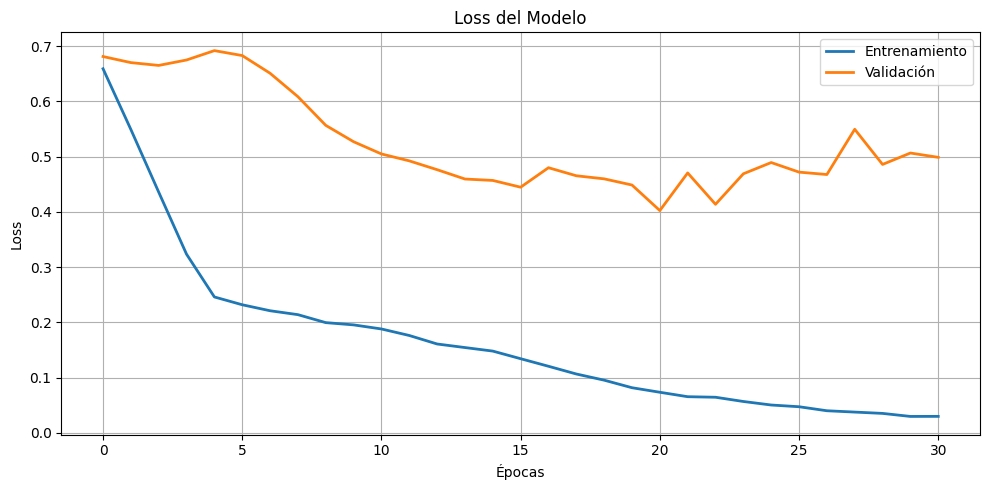

In [42]:
#==========================================================================================
# CURVA DE LOSS
#==========================================================================================

plt.figure(figsize=(10,5))

plt.plot(
    historial.history["loss"],
    label="Entrenamiento",
    linewidth=2
)

plt.plot(
    historial.history["val_loss"],
    label="Validación",
    linewidth=2
)

plt.title("Loss del Modelo")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(
    f"loss_{EXPERIMENTO}.png",
    dpi=300
)

plt.show()

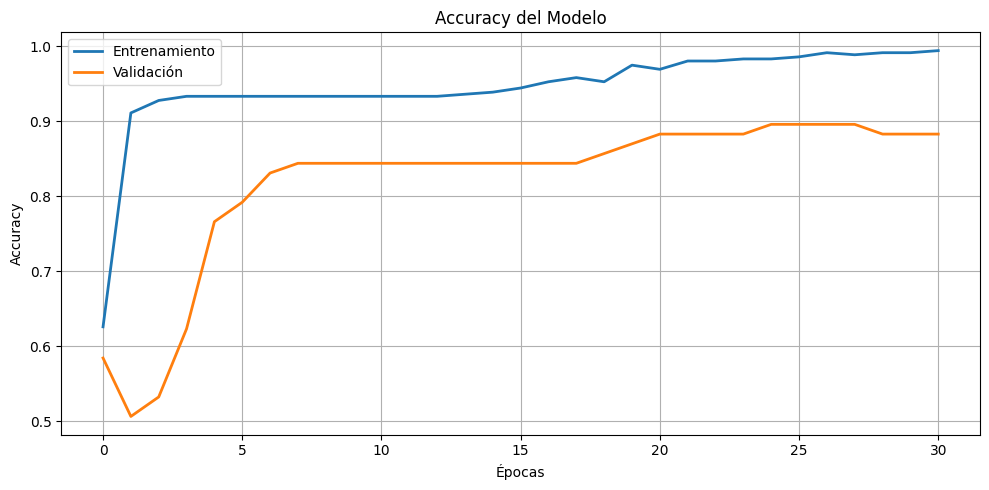

In [43]:
#==========================================================================================
# CURVA DE ACCURACY / MÉTRICA PRINCIPAL
#==========================================================================================

plt.figure(figsize=(10,5))

if TIPO_PROBLEMA.lower() == "clasificación":
    plt.plot(
        historial.history["accuracy"],
        label="Entrenamiento",
        linewidth=2
    )
    plt.plot(
        historial.history["val_accuracy"],
        label="Validación",
        linewidth=2
    )
    plt.title("Accuracy del Modelo")
    plt.ylabel("Accuracy")
elif TIPO_PROBLEMA.lower() == "regresión":
    plt.plot(
        historial.history["mae"],
        label="Entrenamiento (MAE)",
        linewidth=2
    )
    plt.plot(
        historial.history["val_mae"],
        label="Validación (MAE)",
        linewidth=2
    )
    plt.title("MAE del Modelo")
    plt.ylabel("MAE")

plt.xlabel("Épocas")
plt.grid(True)
plt.legend()
plt.tight_layout()

# Save the plot with a dynamic name based on problem type and experiment
if TIPO_PROBLEMA.lower() == "clasificación":
    plt.savefig(
        f"accuracy_{EXPERIMENTO}.png",
        dpi=300
    )
elif TIPO_PROBLEMA.lower() == "regresión":
    plt.savefig(
        f"mae_{EXPERIMENTO}.png",
        dpi=300
    )

plt.show()

In [44]:
#==========================================================================================
# EXPORTACIÓN
#==========================================================================================

print()

print("="*90)
print("GRÁFICAS EXPORTADAS")
print("="*90)

print()

print(f"loss_{EXPERIMENTO}.png")

if TIPO_PROBLEMA.lower() == "clasificación":

    print(f"accuracy_{EXPERIMENTO}.png")

else:

    print(f"mae_{EXPERIMENTO}.png")


GRÁFICAS EXPORTADAS

loss_Exp01.png
accuracy_Exp01.png


## **M8. Guardar el modelo entrenado**

In [45]:
#==========================================================================================
# M8. GUARDAR EL MODELO ENTRENADO
#==========================================================================================

import os

CARPETA_MODELOS = f"modelos/{EXPERIMENTO}"

os.makedirs(

    CARPETA_MODELOS,

    exist_ok=True

)

NOMBRE_MODELO = f"modelo_{EXPERIMENTO}_{VARIABLE_OBJETIVO}.keras"

RUTA_MODELO = os.path.join(

    CARPETA_MODELOS,

    NOMBRE_MODELO

)

modelo.save(

    RUTA_MODELO

)

print()

print("="*90)
print("MODELO EXPORTADO")
print("="*90)

print()

print(f"Experimento       : {EXPERIMENTO}")
print(f"Tipo problema     : {TIPO_PROBLEMA}")
print(f"Variable objetivo : {VARIABLE_OBJETIVO}")

print()

print("Ruta del modelo:")

print(RUTA_MODELO)


MODELO EXPORTADO

Experimento       : Exp01
Tipo problema     : Clasificación
Variable objetivo : irca

Ruta del modelo:
modelos/Exp01/modelo_Exp01_irca.keras


## **M9. Registro del Experimento**

In [46]:
#==========================================================================================
# FECHA DEL EXPERIMENTO
#==========================================================================================

from datetime import datetime

FECHA_EJECUCION = datetime.now()

print()

print("="*90)
print("FECHA DEL EXPERIMENTO")
print("="*90)

print()

print(FECHA_EJECUCION)


FECHA DEL EXPERIMENTO

2026-08-11 16:22:48.586287


In [47]:
#==========================================================================================
# REGISTRO DEL EXPERIMENTO
#==========================================================================================

registro_dict = {
    "Experimento": [EXPERIMENTO],
    "Fecha": [FECHA_EJECUCION],
    "Dominio": [DOMINIO],
    "Variable_Objetivo": [VARIABLE_OBJETIVO],
    "Modelo": [TIPO_MODELO],
    "Metodo_Transformacion": [METODO_TRANSFORMACION],
    "Ventana": [X.shape[1]],
    "Variables_Predictoras": [X.shape[2]],
    "Muestras": [X.shape[0]],
    "Train": [len(X_train)],
    "Validacion": [len(X_valid)],
    "Prueba": [len(X_test)],
    "Neuronas": [UNIDADES_LSTM],
    "Dropout": [DROPOUT],
    "Learning_Rate": [LEARNING_RATE],
    "Batch_Size": [BATCH_SIZE],
    "Epocas_Config": [EPOCAS],
    "Epocas_Ejecutadas": [len(historial.history["loss"])],
    "Loss_Train": [LOSS_FINAL],
    "Loss_Validacion": [VAL_LOSS_FINAL],
    "Loss_Prueba": [LOSS_TEST]
}

if TIPO_PROBLEMA.lower() == "clasificación":
    registro_dict["Accuracy_Train"] = [ACC_FINAL]
    registro_dict["Accuracy_Validacion"] = [VAL_ACC_FINAL]
    registro_dict["Accuracy_Prueba"] = [ACC_TEST]
elif TIPO_PROBLEMA.lower() == "regresión":
    registro_dict["MAE_Train"] = [MAE_FINAL]
    registro_dict["MAE_Validacion"] = [VAL_MAE_FINAL]
    registro_dict["RMSE_Train"] = [RMSE_FINAL]
    registro_dict["RMSE_Validacion"] = [VAL_RMSE_FINAL]
    registro_dict["MAE_Prueba"] = [MAE_TEST]
    registro_dict["RMSE_Prueba"] = [RMSE_TEST]

if TIPO_PROBLEMA.lower() == "clasificación":
    registro_dict["Accuracy"] = [accuracy]
    registro_dict["Precision"] = [precision]
    registro_dict["Recall"] = [recall]
    registro_dict["F1_Score"] = [f1]
    registro_dict["Especificidad"] = [especificidad]
    registro_dict["Accuracy_Balanceada"] = [accuracy_balanceada]
else:
    registro_dict["Accuracy"] = [None]
    registro_dict["Precision"] = [None]
    registro_dict["Recall"] = [None]
    registro_dict["F1_Score"] = [None]
    registro_dict["Especificidad"] = [None]
    registro_dict["Accuracy_Balanceada"] = [None]

registro_dict["Estado_General"] = [estado]
registro_dict["Tiempo_Segundos"] = [TIEMPO_ENTRENAMIENTO]

registro = pd.DataFrame(registro_dict)

print()
print("="*90)
print("REGISTRO DEL EXPERIMENTO")
print("="*90)
print()

display(registro)


REGISTRO DEL EXPERIMENTO



,Experimento,Fecha,Dominio,Variable_Objetivo,Modelo,Metodo_Transformacion,Ventana,Variables_Predictoras,Muestras,Train,...,Accuracy_Validacion,Accuracy_Prueba,Accuracy,Precision,Recall,F1_Score,Especificidad,Accuracy_Balanceada,Estado_General,Tiempo_Segundos
0,Exp01,2026-08-11 16:22:48.586287,Gestión Hídrica,irca,LSTM,RobustScaler,12,8,516,361,...,0.883117,0.846154,0.846154,0.0,0.0,0.0,1.0,0.5,Bueno,17.90418


In [48]:
#==========================================================================================
# EXPORTACIÓN
#==========================================================================================

nombre_csv = f"registro_{EXPERIMENTO}.csv"

nombre_excel = f"registro_{EXPERIMENTO}.xlsx"

registro.to_csv(

    nombre_csv,

    index=False,

    encoding="utf-8-sig"

)

registro.to_excel(

    nombre_excel,

    index=False

)

print()

print("="*90)
print("ARCHIVOS GENERADOS")
print("="*90)

print()

print(nombre_csv)

print(nombre_excel)


ARCHIVOS GENERADOS

registro_Exp01.csv
registro_Exp01.xlsx


In [49]:
#==========================================================================================
# RESUMEN
#==========================================================================================

print()

print("="*90)
print("FRAMEWORK DE MODELADO FINALIZADO")
print("="*90)

print()

print(f"Experimento        : {EXPERIMENTO}")

print(f"Modelo             : {TIPO_MODELO}")

print(f"Objetivo           : {VARIABLE_OBJETIVO}")

print(f"Muestras           : {len(X)}")

if TIPO_PROBLEMA == "Clasificación":
    print(f"Accuracy Prueba    : {ACC_TEST:.4f}")
elif TIPO_PROBLEMA == "Regresión":
    print(f"MAE Prueba         : {MAE_TEST:.4f}")
    print(f"RMSE Prueba        : {RMSE_TEST:.4f}")

print(f"Tiempo             : {TIEMPO_ENTRENAMIENTO:.2f} segundos")

print()

print("Proceso completado correctamente.")


FRAMEWORK DE MODELADO FINALIZADO

Experimento        : Exp01
Modelo             : LSTM
Objetivo           : irca
Muestras           : 516
Accuracy Prueba    : 0.8462
Tiempo             : 17.90 segundos

Proceso completado correctamente.


## **M10. Bitácora Maestra**

In [50]:
#==========================================================================================
# BITÁCORA MAESTRA DEL FRAMEWORK
#==========================================================================================

import os

ARCHIVO_BITACORA = "bitacora_maestra_experimentos.xlsx"

print()

print("="*90)
print("BITÁCORA MAESTRA")
print("="*90)

print()

print(ARCHIVO_BITACORA)


BITÁCORA MAESTRA

bitacora_maestra_experimentos.xlsx


In [51]:
#==========================================================================================
# CARGA DE LA BITÁCORA
#==========================================================================================

if os.path.exists(ARCHIVO_BITACORA):

    bitacora = pd.read_excel(

        ARCHIVO_BITACORA

    )

else:

    bitacora = pd.DataFrame()

In [52]:
#==========================================================================================
# AGREGAR REGISTRO Y ORDENAMIENTO
#==========================================================================================

# Agregar el registro del experimento actual a la bitácora
if bitacora.empty:
    bitacora = registro.copy()
else:
    bitacora = pd.concat([bitacora, registro], ignore_index=True)

# Ordenar la bitácora
if not bitacora.empty:
    bitacora = bitacora.sort_values(
        by="Experimento"
    ).reset_index(
        drop=True
    )

In [53]:
#==========================================================================================
# EXPORTACIÓN
#==========================================================================================

bitacora.to_excel(

    ARCHIVO_BITACORA,

    index=False

)

bitacora.to_csv(

    "bitacora_maestra_experimentos.csv",

    index=False,

    encoding="utf-8-sig"

)

In [54]:
#==========================================================================================
# HISTÓRICO
#==========================================================================================

print()

print("="*90)
print("HISTÓRICO DEL FRAMEWORK")
print("="*90)

print()

display(bitacora)


HISTÓRICO DEL FRAMEWORK



,Experimento,Fecha,Dominio,Variable_Objetivo,Modelo,Metodo_Transformacion,Ventana,Variables_Predictoras,Muestras,Train,...,Accuracy_Validacion,Accuracy_Prueba,Accuracy,Precision,Recall,F1_Score,Especificidad,Accuracy_Balanceada,Estado_General,Tiempo_Segundos
0,Exp01,2026-08-11 16:16:37.965000,Gestión Hídrica,irca,LSTM,RobustScaler,12,8,516,361,...,0.844156,0.846154,0.846154,0.0,0.0,0.0,1.0,0.5,Bueno,5.749446
1,Exp01,2026-08-11 16:22:48.586287,Gestión Hídrica,irca,LSTM,RobustScaler,12,8,516,361,...,0.883117,0.846154,0.846154,0.0,0.0,0.0,1.0,0.5,Bueno,17.904180


## **M11. Centro Analítico del Framework**

In [55]:
#==========================================================================================
# SCRIPT 43
# CENTRO ANALÍTICO DEL FRAMEWORK
#==========================================================================================

import pandas as pd

ARCHIVO_BITACORA = "bitacora_maestra_experimentos.xlsx"

bitacora = pd.read_excel(

    ARCHIVO_BITACORA

)

print()

print("="*90)
print("CENTRO ANALÍTICO DEL FRAMEWORK")
print("="*90)

print()

display(bitacora.head())


CENTRO ANALÍTICO DEL FRAMEWORK



,Experimento,Fecha,Dominio,Variable_Objetivo,Modelo,Metodo_Transformacion,Ventana,Variables_Predictoras,Muestras,Train,...,Accuracy_Validacion,Accuracy_Prueba,Accuracy,Precision,Recall,F1_Score,Especificidad,Accuracy_Balanceada,Estado_General,Tiempo_Segundos
0,Exp01,2026-08-11 16:16:37.965,Gestión Hídrica,irca,LSTM,RobustScaler,12,8,516,361,...,0.844156,0.846154,0.846154,0,0,0,1,0.5,Bueno,5.749446
1,Exp01,2026-08-11 16:22:48.586,Gestión Hídrica,irca,LSTM,RobustScaler,12,8,516,361,...,0.883117,0.846154,0.846154,0,0,0,1,0.5,Bueno,17.904180


In [56]:
import pandas as pd

#==========================================================================================
# RESUMEN GENERAL
#==========================================================================================

print()

print("="*90)
print("RESUMEN GENERAL")
print("="*90)

print()

if not bitacora.empty:
    print(f"Experimentos ejecutados : {len(bitacora)}")
    print(f"Modelos utilizados      : {bitacora['Modelo'].nunique()}")
    print(f"Variables objetivo      : {bitacora['Variable_Objetivo'].nunique()}")

    if 'Accuracy_Prueba' in bitacora.columns and bitacora['Accuracy_Prueba'].notna().any():
        print(f"Accuracy promedio       : {bitacora['Accuracy_Prueba'].mean():.4f}")

    if 'MAE_Prueba' in bitacora.columns and bitacora['MAE_Prueba'].notna().any():
        print(f"MAE promedio            : {bitacora['MAE_Prueba'].mean():.4f}")

    if 'RMSE_Prueba' in bitacora.columns and bitacora['RMSE_Prueba'].notna().any():
        print(f"RMSE promedio           : {bitacora['RMSE_Prueba'].mean():.4f}")

    print(f"Loss promedio           : {bitacora['Loss_Prueba'].mean():.4f}")
    print(f"Tiempo promedio (s)     : {bitacora['Tiempo_Segundos'].mean():.2f}")
else:
    print("La bitácora está vacía. No se pueden generar estadísticas.")


RESUMEN GENERAL

Experimentos ejecutados : 2
Modelos utilizados      : 1
Variables objetivo      : 1
Accuracy promedio       : 0.8462
Loss promedio           : 0.8427
Tiempo promedio (s)     : 11.83


In [57]:
import numpy as np

print('\n==========================================================================================')
print('DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (y)')
print('==========================================================================================\n')

# Obtener los valores únicos y sus conteos del array y
unique_values, counts = np.unique(y, return_counts=True)

for val, count in zip(unique_values, counts):
    print(f"Valor '{int(val)}': {count} ocurrencias")


DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (y)

Valor '0': 468 ocurrencias
Valor '1': 48 ocurrencias
